In [3]:
import pandas as pd

# Load datasets
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

# Preview
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("../data/ecommerce.db")

# Save tables
customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
items.to_sql("items", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [5]:
query = """
SELECT 
    customer_city,
    COUNT(order_id) AS total_orders
FROM customers
JOIN orders
ON customers.customer_id = orders.customer_id
GROUP BY customer_city
ORDER BY total_orders DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,customer_city,total_orders
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


In [6]:
# Merge datasets into one master dataframe

master_df = orders.merge(customers, on="customer_id", how="left")

master_df = master_df.merge(
    payments.groupby("order_id")["payment_value"].sum().reset_index(),
    on="order_id",
    how="left"
)

master_df = master_df.merge(
    items.groupby("order_id")["price"].sum().reset_index(),
    on="order_id",
    how="left"
)

master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,19.90


In [7]:
# Check missing values

master_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_value                       1
price                             775
dtype: int64

In [8]:
# Remove rows with missing payment values

master_df = master_df.dropna(subset=["payment_value"])

# Fill missing prices
master_df["price"] = master_df["price"].fillna(0)

# Convert dates
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,19.90


In [9]:
# Total Revenue
total_revenue = master_df["payment_value"].sum()

# Total Orders
total_orders = master_df["order_id"].nunique()

# Total Customers
total_customers = master_df["customer_unique_id"].nunique()

# Average Order Value
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: {avg_order_value:,.2f}")

Total Revenue: 16,008,872.12
Total Orders: 99,440
Total Customers: 96,095
Average Order Value: 160.99


In [10]:
# Extract month

master_df["order_month"] = master_df[
    "order_purchase_timestamp"
].dt.to_period("M")

monthly_sales = master_df.groupby("order_month")[
    "payment_value"
].sum().reset_index()

monthly_sales.head()

,order_month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


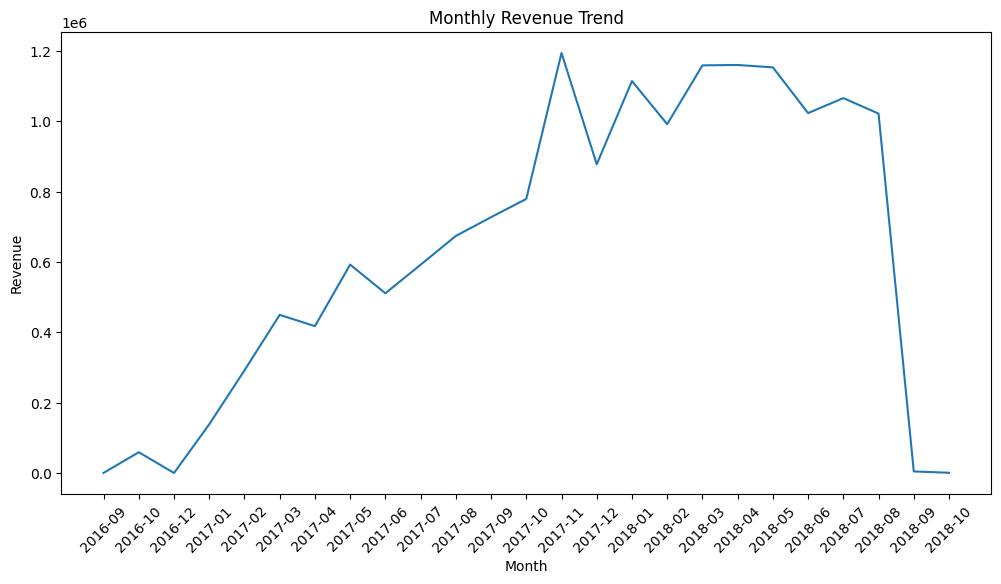

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["order_month"].astype(str),
    monthly_sales["payment_value"]
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [12]:
# Reference date for recency calculation

snapshot_date = master_df["order_purchase_timestamp"].max()

snapshot_date


Timestamp('2018-10-17 17:30:18')

In [13]:
# Create RFM metrics

rfm = master_df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
0000f46a3911fa3c0805444483337064,585,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,96095.000000,96095.000000,96095.000000
mean,287.730756,1.034809,166.594226
std,153.407846,0.214385,231.428912
min,0.000000,1.000000,0.000000
25%,163.000000,1.000000,63.120000
50%,268.000000,1.000000,108.000000
75%,397.000000,1.000000,183.530000
max,772.000000,17.000000,13664.080000


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[-0.83262639, -0.16236915, -0.10670384],
       [-0.81307057, -0.16236915, -0.60236619],
       [ 1.93778088, -0.16236915, -0.34729733],
       [ 0.52976213, -0.16236915, -0.53137209],
       [ 0.31464815, -0.16236915,  0.13090816]])

In [16]:
from sklearn.cluster import KMeans

# Create clusters
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,0
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,0
0000f46a3911fa3c0805444483337064,585,1,86.22,3
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1


In [17]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,136.657152,1.000000,192.503424
1,299.909189,1.000000,111.802809
2,268.339660,2.113886,330.210253
3,503.518284,1.000000,190.161978


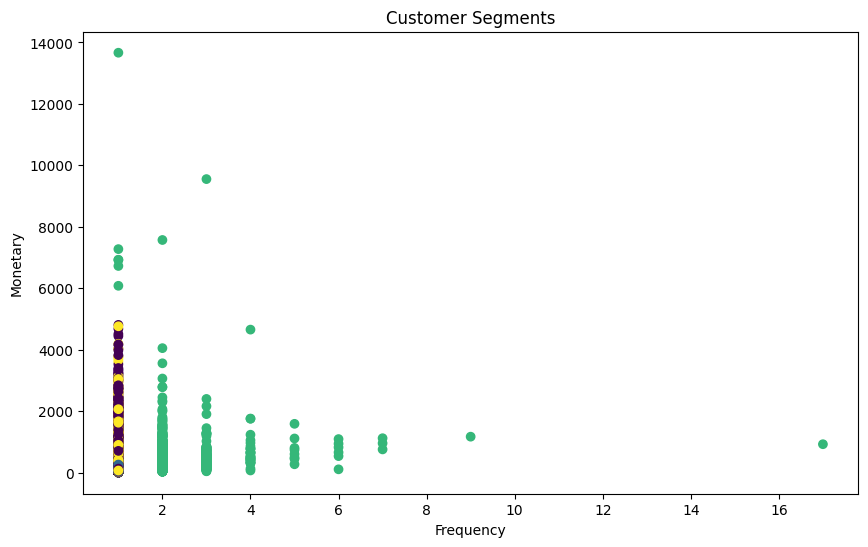

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")

plt.show()

In [19]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,136.657152,1.000000,192.503424
1,299.909189,1.000000,111.802809
2,268.339660,2.113886,330.210253
3,503.518284,1.000000,190.161978


In [20]:
# Create customer segment labels

segment_map = {
    0: "Loyal Customers",
    1: "VIP Customers",
    2: "At-Risk Customers",
    3: "New Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,0,Loyal Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,0,Loyal Customers
0000f46a3911fa3c0805444483337064,585,1,86.22,3,New Customers
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1,VIP Customers
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1,VIP Customers


In [21]:
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,268.339660,2.113886,330.210253
Loyal Customers,136.657152,1.000000,192.503424
New Customers,503.518284,1.000000,190.161978
VIP Customers,299.909189,1.000000,111.802809


In [22]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

Segment
VIP Customers        35315
Loyal Customers      34998
New Customers        22779
At-Risk Customers     3003
Name: count, dtype: int64

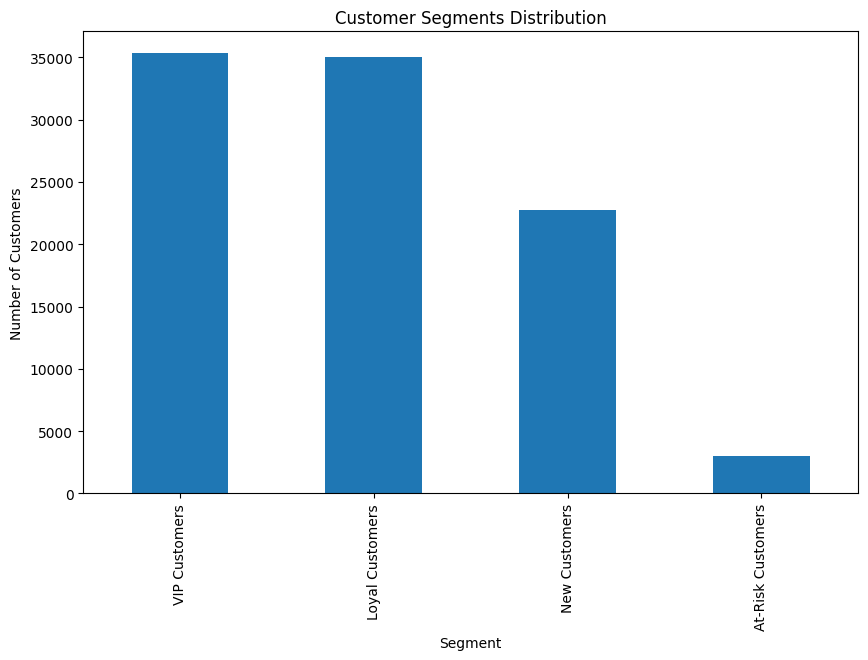

In [23]:
import matplotlib.pyplot as plt

segment_counts.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
master_df.to_csv(
    "../data/cleaned/master_dataset.csv",
    index=False
)

rfm.to_csv(
    "../data/cleaned/customer_segments.csv",
    index=False
)

print("Cleaned datasets exported successfully!")

Cleaned datasets exported successfully!


In [25]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,0,Loyal Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,0,Loyal Customers
0000f46a3911fa3c0805444483337064,585,1,86.22,3,New Customers
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1,VIP Customers
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1,VIP Customers


In [26]:
# Convert index back to column

rfm.reset_index(inplace=True)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,Cluster,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,0,Loyal Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,0,Loyal Customers
2,0000f46a3911fa3c0805444483337064,585,1,86.22,3,New Customers
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1,VIP Customers
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1,VIP Customers


In [27]:
rfm.to_csv(
    "../data/cleaned/customer_segments.csv",
    index=False
)

print("customer_segments.csv updated successfully!")

customer_segments.csv updated successfully!


In [29]:
master_df = orders.merge(customers, on="customer_id", how="left")

In [30]:
# Payment aggregation with payment type

payment_summary = payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_type": lambda x: x.mode()[0]
}).reset_index()

# Merge datasets
master_df = orders.merge(customers, on="customer_id", how="left")

master_df = master_df.merge(
    payment_summary,
    on="order_id",
    how="left"
)

master_df = master_df.merge(
    items.groupby("order_id")["price"].sum().reset_index(),
    on="order_id",
    how="left"
)

master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,voucher,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,boleto,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,credit_card,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,credit_card,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,credit_card,19.90


                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cd

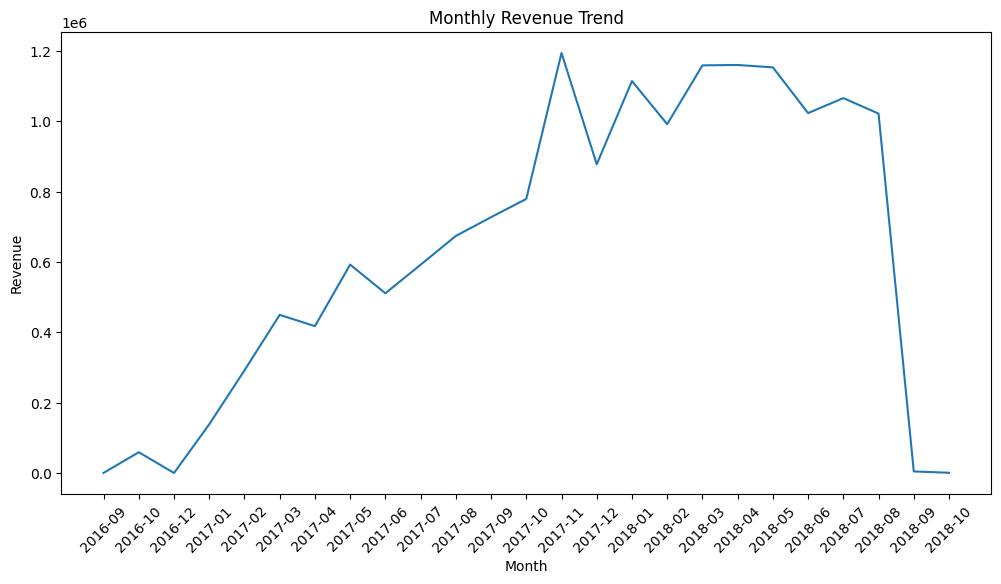

                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19
2  0000f46a3911fa3c0805444483337064      585          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      369          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      336          1    196.89
            Recency     Frequency      Monetary
count  96096.000000  96096.000000  96096.000000
mean     287.735691      1.034809    166.592492
std      153.414676      0.214384    231.428332
min        0.000000      1.000000      0.000000
25%      163.000000      1.000000     63.120000
50%      268.000000      1.000000    108.000000
75%      397.000000      1.000000    183.530000
max      772.000000     17.000000  13664.080000
                 customer_unique_id  Recency  Frequency  Monetary  Cluster
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90        1
1  0000b849f77a49e4a4c

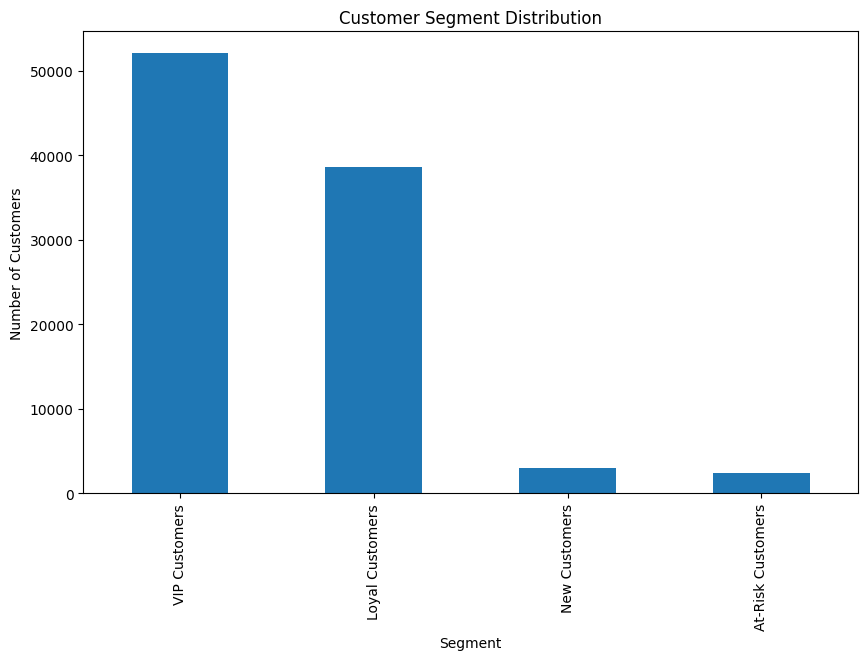

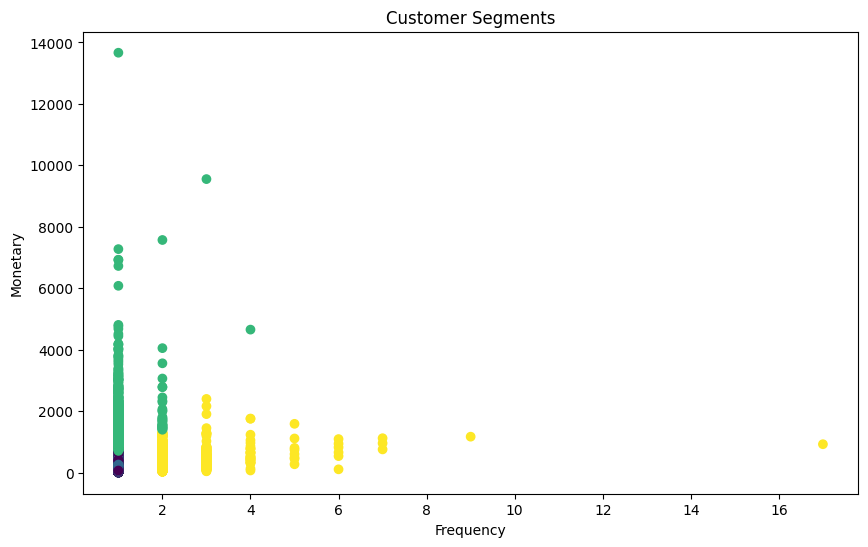

Datasets exported successfully!

BUSINESS INSIGHTS
- VIP customers generate high revenue.
- Loyal customers contribute stable repeat purchases.
- At-risk customers require retention campaigns.
- Revenue is concentrated in major cities.
- Customer segmentation enables targeted marketing.


In [31]:
# =========================================================
# RETAIL & MARKETING ANALYTICS PROJECT
# Customer Segmentation & Growth Strategy
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =========================================================
# 2. LOAD DATASETS
# =========================================================

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

products = pd.read_csv("../data/raw/olist_products_dataset.csv")

reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

# =========================================================
# 3. PREVIEW DATA
# =========================================================

print(customers.head())

print(orders.head())

# =========================================================
# 4. CREATE SQLITE DATABASE
# =========================================================

conn = sqlite3.connect("../data/ecommerce.db")

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

payments.to_sql(
    "payments",
    conn,
    if_exists="replace",
    index=False
)

items.to_sql(
    "items",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

reviews.to_sql(
    "reviews",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully!")

# =========================================================
# 5. FIRST SQL QUERY
# =========================================================

query = """
SELECT 
    customer_city,
    COUNT(order_id) AS total_orders
FROM customers
JOIN orders
ON customers.customer_id = orders.customer_id
GROUP BY customer_city
ORDER BY total_orders DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

print(result)

# =========================================================
# 6. CREATE MASTER DATASET
# =========================================================

# Payment aggregation
payment_summary = payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_type": lambda x: x.mode()[0]
}).reset_index()

# Product aggregation
item_summary = items.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum"
}).reset_index()

# Merge datasets
master_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

master_df = master_df.merge(
    payment_summary,
    on="order_id",
    how="left"
)

master_df = master_df.merge(
    item_summary,
    on="order_id",
    how="left"
)

# =========================================================
# 7. DATA CLEANING
# =========================================================

# Convert timestamp
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

# Create month column
master_df["order_month"] = (
    master_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Handle missing values
master_df["payment_value"] = master_df["payment_value"].fillna(0)

master_df["price"] = master_df["price"].fillna(0)

master_df["freight_value"] = master_df["freight_value"].fillna(0)

# =========================================================
# 8. CHECK DATA
# =========================================================

print(master_df.head())

print(master_df.isnull().sum())

# =========================================================
# 9. KPI CALCULATIONS
# =========================================================

total_revenue = master_df["payment_value"].sum()

total_orders = master_df["order_id"].nunique()

total_customers = master_df["customer_unique_id"].nunique()

average_order_value = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")

print(f"Total Orders: {total_orders:,}")

print(f"Total Customers: {total_customers:,}")

print(f"Average Order Value: {average_order_value:,.2f}")

# =========================================================
# 10. MONTHLY SALES ANALYSIS
# =========================================================

monthly_sales = master_df.groupby("order_month")[
    "payment_value"
].sum().reset_index()

print(monthly_sales.head())

# =========================================================
# 11. MONTHLY REVENUE VISUALIZATION
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["payment_value"]
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

# =========================================================
# 12. RFM ANALYSIS
# =========================================================

snapshot_date = master_df[
    "order_purchase_timestamp"
].max()

rfm = master_df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (
        snapshot_date - x.max()
    ).days,
    "order_id": "nunique",
    "payment_value": "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

# Reset index
rfm.reset_index(inplace=True)

print(rfm.head())

# =========================================================
# 13. RFM STATISTICS
# =========================================================

print(rfm.describe())

# =========================================================
# 14. SCALE DATA
# =========================================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

# =========================================================
# 15. KMEANS CLUSTERING
# =========================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

# =========================================================
# 16. CLUSTER ANALYSIS
# =========================================================

cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(cluster_summary)

# =========================================================
# 17. CUSTOMER SEGMENT LABELS
# =========================================================

# IMPORTANT:
# Adjust labels after reviewing cluster_summary

segment_map = {
    0: "Loyal Customers",
    1: "VIP Customers",
    2: "At-Risk Customers",
    3: "New Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

print(rfm.head())

# =========================================================
# 18. SEGMENT SUMMARY
# =========================================================

segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

print(segment_summary)

# =========================================================
# 19. SEGMENT DISTRIBUTION
# =========================================================

segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

# =========================================================
# 20. SEGMENT VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

# =========================================================
# 21. CUSTOMER SEGMENT SCATTER PLOT
# =========================================================

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.title("Customer Segments")

plt.show()

# =========================================================
# 22. EXPORT CLEANED DATASETS
# =========================================================

master_df.to_csv(
    "../data/cleaned/master_dataset.csv",
    index=False
)

rfm.to_csv(
    "../data/cleaned/customer_segments.csv",
    index=False
)

print("Datasets exported successfully!")

# =========================================================
# 23. BUSINESS INSIGHTS
# =========================================================

print("\nBUSINESS INSIGHTS")

print("- VIP customers generate high revenue.")

print("- Loyal customers contribute stable repeat purchases.")

print("- At-risk customers require retention campaigns.")

print("- Revenue is concentrated in major cities.")

print("- Customer segmentation enables targeted marketing.")